In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [4]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [5]:
df["target"] = df["target"].map({0: "malignant", 1: "benign"})
df["target"].value_counts()

target
benign       357
malignant    212
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [8]:
df.isnull().sum().sort_values(ascending=False).head(10)

mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64

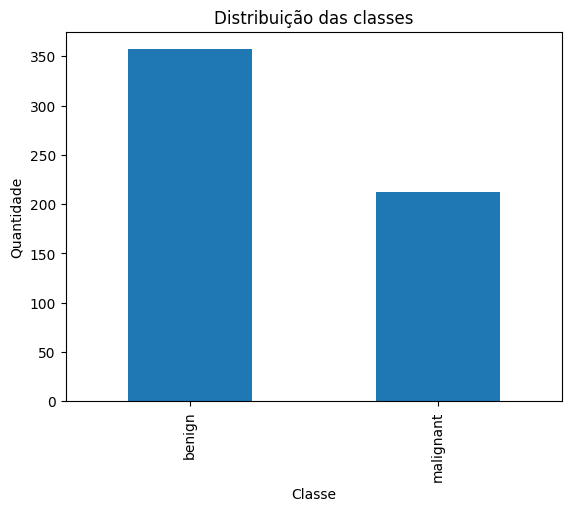

In [9]:
df["target"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

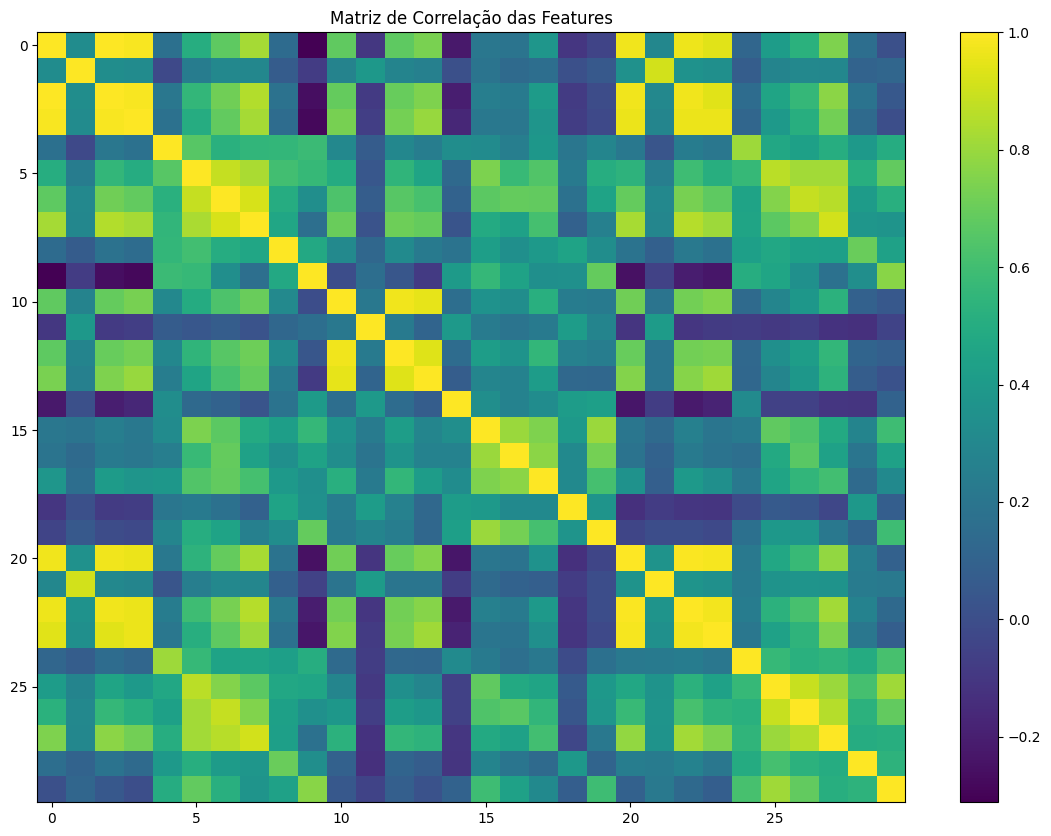

In [10]:
corr = df.drop(columns="target").corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Matriz de Correlação das Features")
plt.show()

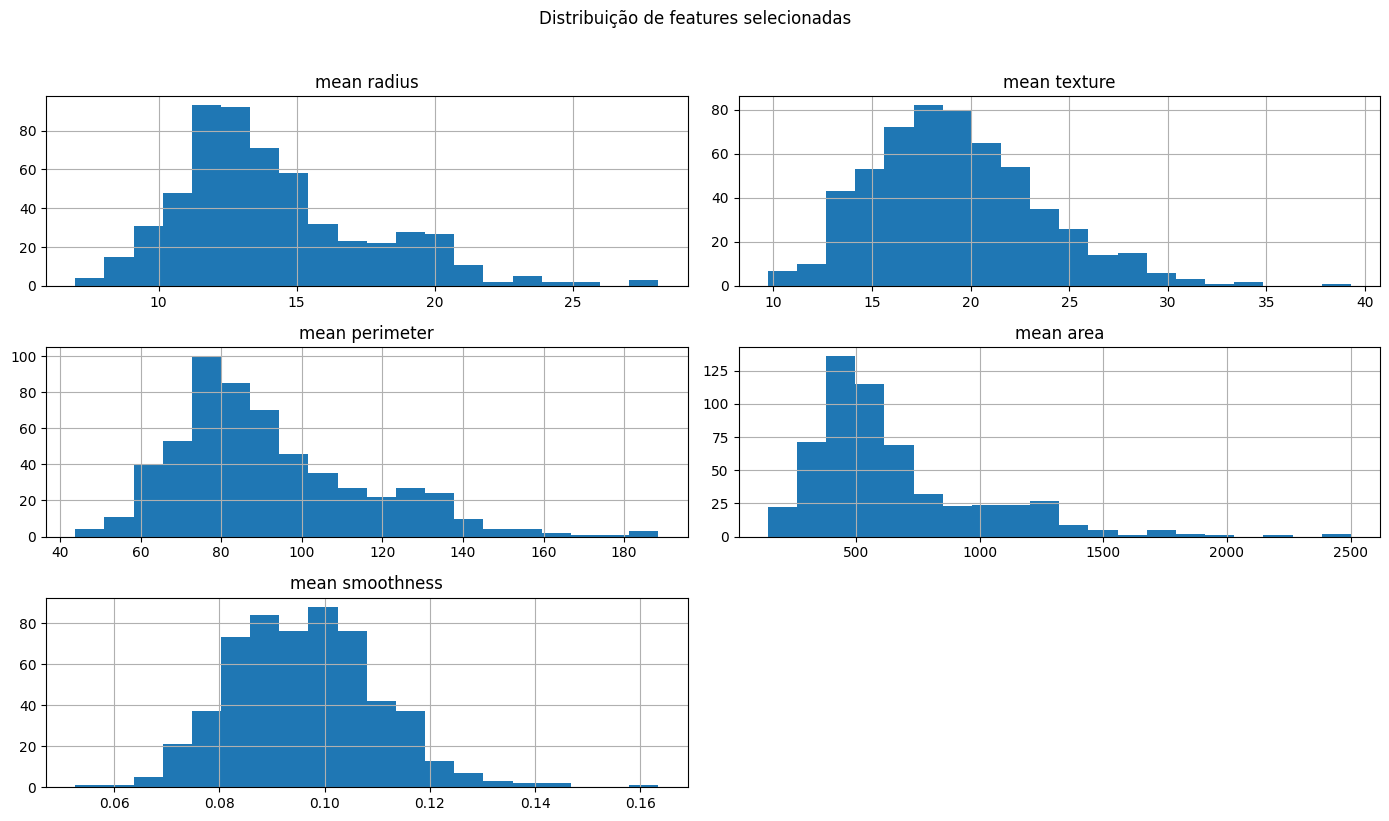

In [11]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

df[selected_features].hist(figsize=(14, 8), bins=20)
plt.suptitle("Distribuição de features selecionadas", y=1.02)
plt.tight_layout()
plt.show()

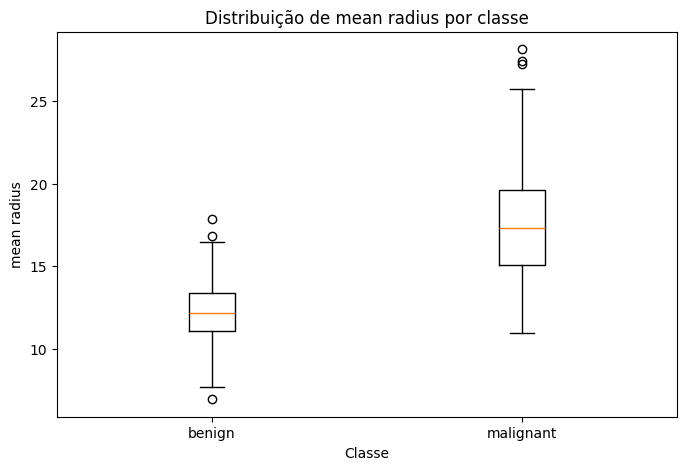

In [12]:
import matplotlib.pyplot as plt

feature = "mean radius"

classes = ["benign", "malignant"]
data_to_plot = [df[df["target"] == c][feature] for c in classes]

plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, tick_labels=classes)
plt.title(f"Distribuição de {feature} por classe")
plt.xlabel("Classe")
plt.ylabel(feature)
plt.show()

In [13]:
target_numeric = load_breast_cancer().target
df_numeric = pd.DataFrame(load_breast_cancer().data, columns=load_breast_cancer().feature_names)
df_numeric["target"] = target_numeric

correlations = df_numeric.corr(numeric_only=True)["target"].drop("target").sort_values()

print("Features mais negativamente correlacionadas com target:")
print(correlations.head(10))
print()
print("Features mais positivamente correlacionadas com target:")
print(correlations.tail(10))

Features mais negativamente correlacionadas com target:
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64

Features mais positivamente correlacionadas com target:
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0.008303
mean fractal dimension     0.012838
smoothness error           0.067016
Name: target, dtype: float64


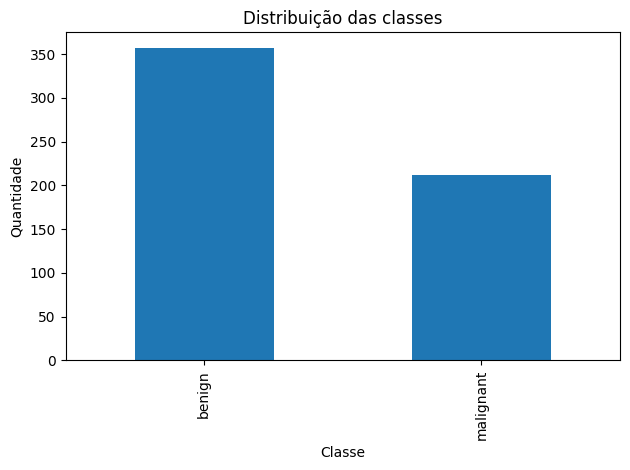

In [14]:
df["target"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig("../figures/class_distribution.png", dpi=300)
plt.show()

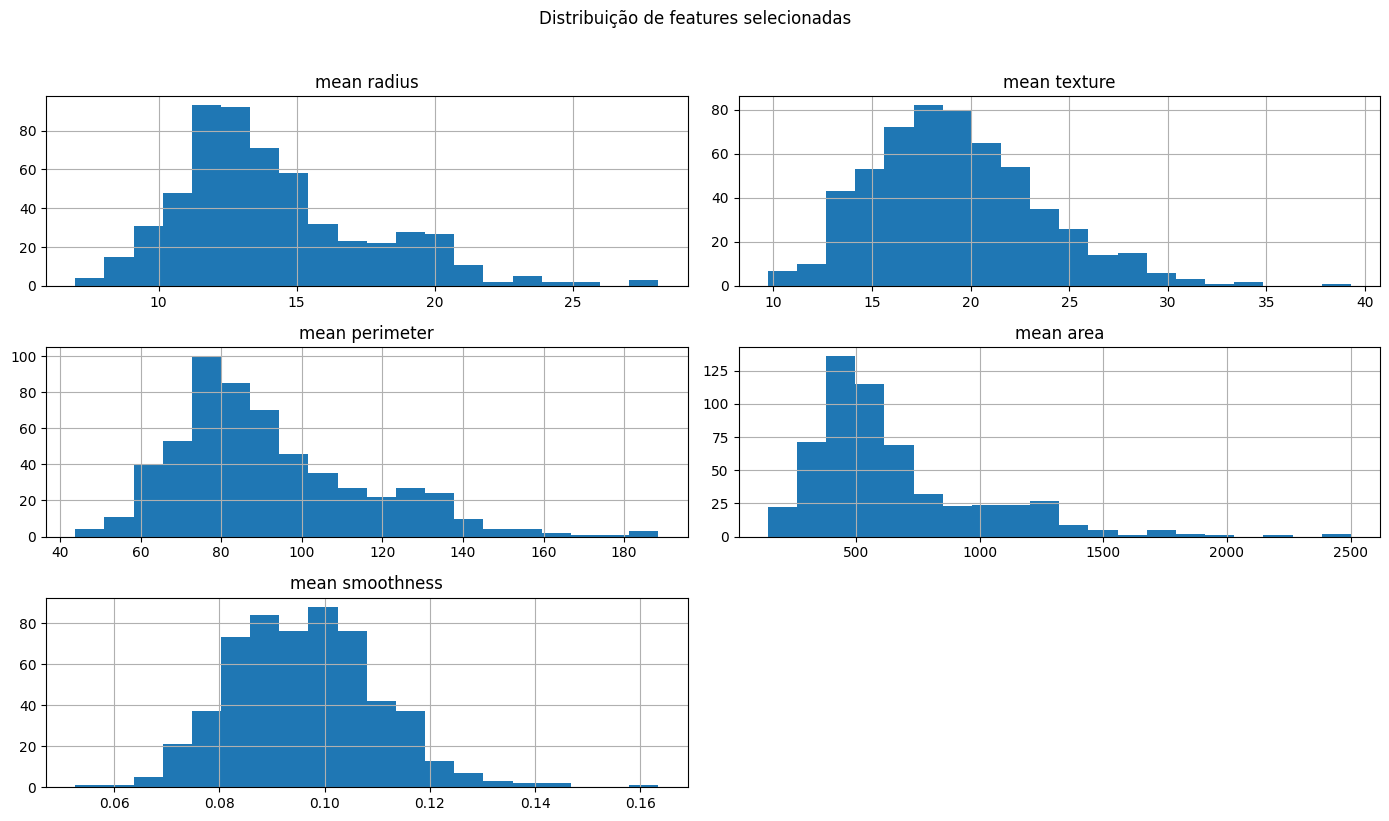

In [15]:
df[selected_features].hist(figsize=(14, 8), bins=20)
plt.suptitle("Distribuição de features selecionadas", y=1.02)
plt.tight_layout()
plt.savefig("../figures/feature_histograms.png", dpi=300)
plt.show()